<a href="https://colab.research.google.com/github/Mediana17/skin-lesion-mobilenetv2/blob/main/KODE_PROGRAM_AI_KELOMPOK_12_4A_IF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **KLASIFIKASI ACNE, ECZEMA, DAN ROSACEA MENGGUNAKAN CONVOLUTIONAL NEURAL NETWORK BERBASIS ARSITEKTUR MOBILENETV2**

In [ ]:
import os
import random
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(42)

import numpy as np
import tensorflow as tf
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

print("TensorFlow version:", tf.__version__)
device = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"
print("Device:", device)

TensorFlow version: 2.19.0
Device: CPU


In [ ]:
base_path = "/kaggle/input/datasets/sponishflea/classification-of-skin-diseases/train"

image_path = []
labels = []

for label in os.listdir(base_path):
    label_path = os.path.join(base_path, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            image_path.append(os.path.join(label_path, image))
            labels.append(label)

df = pd.DataFrame({"image_path": image_path, "labels": labels})
print("Total images:", len(df))
print("Unique labels:", df["labels"].unique())

Total images: 1494
Unique labels: ['eksim' 'panu' 'acne' 'rosacea' 'herpes']


In [ ]:
desired_classes = ["acne", "eksim", "rosacea"]
df_filtered = df[df["labels"].isin(desired_classes)].reset_index(drop=True)

print("Filtered dataset shape:", df_filtered.shape)
print("Class distribution:")
print(df_filtered["labels"].value_counts())

Filtered dataset shape: (897, 2)
Class distribution:
labels
acne       300
rosacea    300
eksim      297
Name: count, dtype: int64


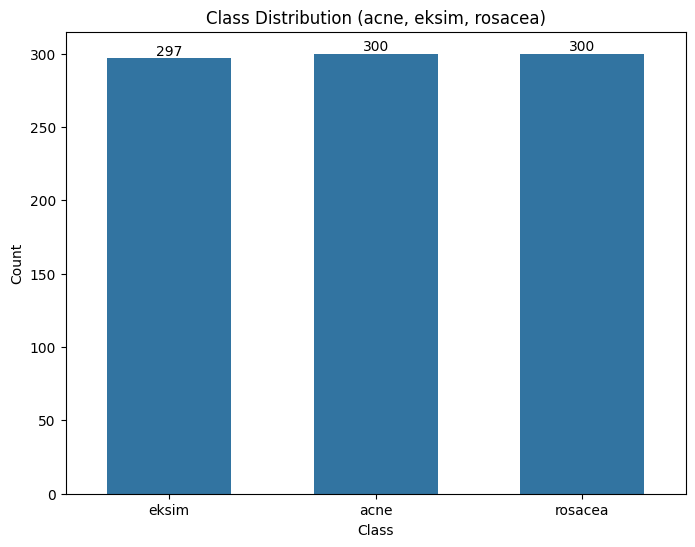

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_filtered, x="labels", width=0.6)
plt.title("Class Distribution (acne, eksim, rosacea)")
plt.xlabel("Class")
plt.ylabel("Count")
for i, p in enumerate(plt.gca().patches):
    plt.gca().annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom')
plt.show()

In [ ]:
train, test = train_test_split(
    df_filtered,
    test_size=0.2,
    stratify=df_filtered["labels"],
    random_state=42
)
test, val = train_test_split(
    test,
    test_size=0.5,
    stratify=test["labels"],
    random_state=42
)

print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")
print(f"Test size: {len(test)}")

Train size: 717
Validation size: 90
Test size: 90


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(df_filtered["labels"])

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} -> {class_name}")

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

0 -> acne
1 -> eksim
2 -> rosacea
Number of classes: 3


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col="image_path",
    y_col="labels",
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val,
    x_col="image_path",
    y_col="labels",
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col="image_path",
    y_col="labels",
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 717 validated image filenames belonging to 3 classes.
Found 90 validated image filenames belonging to 3 classes.
Found 90 validated image filenames belonging to 3 classes.
Class mapping: {'acne': 0, 'eksim': 1, 'rosacea': 2}


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 30s 560ms/step - accuracy: 0.5830 - loss: 0.9387 - val_accuracy: 0.6667 - val_loss: 0.6453 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 538ms/step - accuracy: 0.6876 - loss: 0.7193 - val_accuracy: 0.7000 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 554ms/step - accuracy: 0.7197 - loss: 0.6530 - val_accuracy: 0.7556 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 524ms/step - accuracy: 0.7420 - loss: 0.6094 - val_accuracy: 0.7556 - val_loss: 0.6199 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 519ms/step - accuracy: 0.7810 - loss: 0.5640 - val_accuracy: 0.7889 - val_loss: 0.4941 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 517ms/step - accuracy: 0.7476 - loss: 0.5657 - val_accuracy: 0.7333 - val_loss: 0.5296 - learning_rate: 0.0010
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 542ms/step - accuracy: 0.7741 - loss: 0.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 659ms/step - accuracy: 0.6750 - loss: 0.9264 - val_accuracy: 0.8333 - val_loss: 0.3927 - learning_rate: 1.0000e-05
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 621ms/step - accuracy: 0.7169 - loss: 0.7641 - val_accuracy: 0.8111 - val_loss: 0.4105 - learning_rate: 1.0000e-05
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 604ms/step - accuracy: 0.7490 - loss: 0.6331 - val_accuracy: 0.8111 - val_loss: 0.4257 - learning_rate: 1.0000e-05
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 615ms/step - accuracy: 0.7699 - loss: 0.5877 - val_accuracy: 0.8000 - val_loss: 0.4308 - learning_rate: 1.0000e-05
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.7969 - loss: 0.5090
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 632ms/step - accuracy: 0.7978 - loss: 0.5142 - val_accuracy: 0.8000 - val_loss: 0.4330 - learning_rate: 1.0000e-05
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 29s 636ms/step - accuracy:

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(
    test_generator.classes,
    y_pred_classes,
    target_names=list(test_generator.class_indices.keys())
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.8333 - loss: 0.5233
Test Accuracy: 0.8333 (83.33%)
Test Loss: 0.5233
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 524ms/step

Classification Report:
              precision    recall  f1-score   support

        acne       0.83      0.80      0.81        30
       eksim       0.86      0.83      0.85        30
     rosacea       0.81      0.87      0.84        30

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.83      0.83      0.83        90



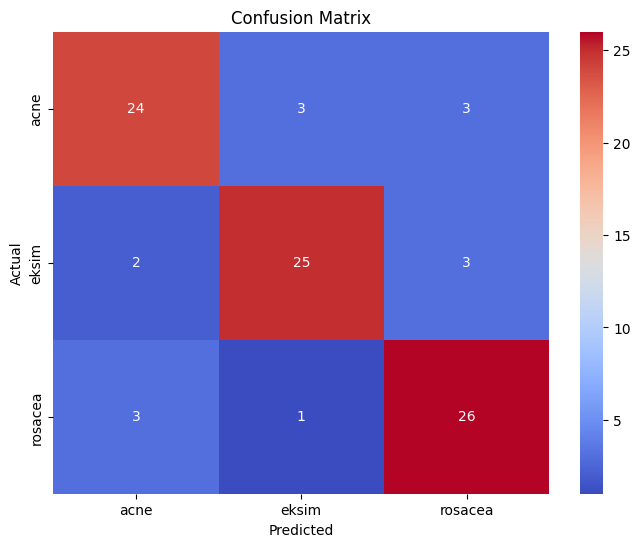

In [ ]:
cm = confusion_matrix(test_generator.classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm",
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

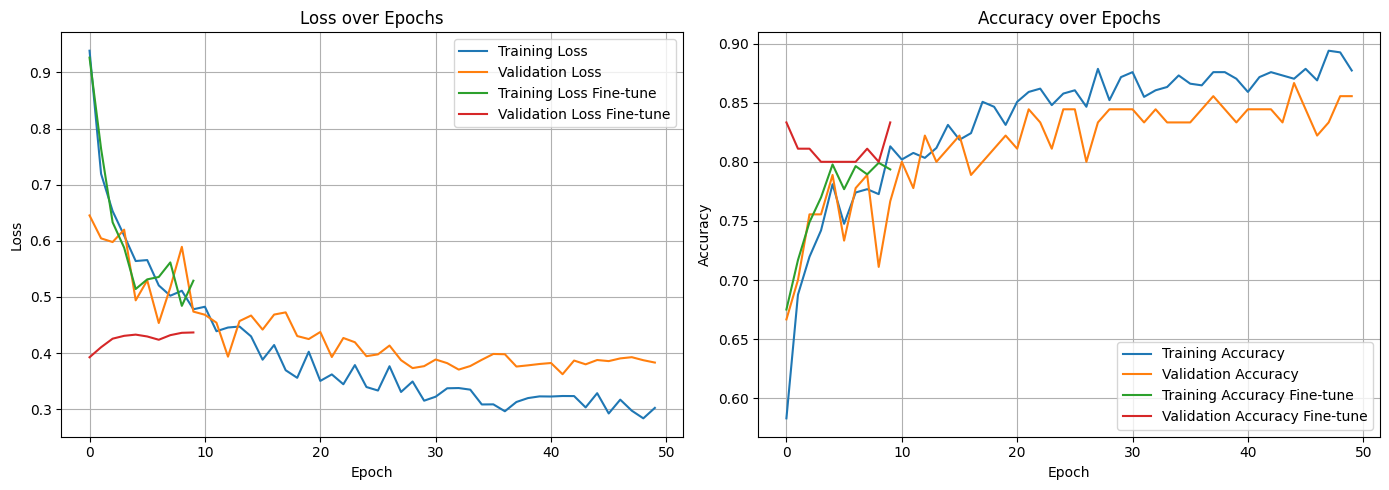

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].plot(history_fine.history["loss"], label="Training Loss Fine-tune")
axes[0].plot(history_fine.history["val_loss"], label="Validation Loss Fine-tune")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Training Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].plot(history_fine.history["accuracy"], label="Training Accuracy Fine-tune")
axes[1].plot(history_fine.history["val_accuracy"], label="Validation Accuracy Fine-tune")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
model.save("mobilenetv2_skin_3classes_ai.h5")
print("Model saved as mobilenetv2_skin_3classes_ai.h5")

Model saved as mobilenetv2_skin_3classes_ai.h5


In [ ]:
from tensorflow.keras.preprocessing import image
from PIL import Image

def predict_and_show(img_path):
    if not os.path.exists(img_path):
        print(f"Error: File not found - {img_path}")
        return None, None

    img = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_resized = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.

    prediction = model.predict(img_array, verbose=0)
    class_idx = np.argmax(prediction[0])
    confidence = prediction[0][class_idx]
    class_name = list(test_generator.class_indices.keys())[class_idx]

    print(f"Image path: {img_path}")
    print(f"Prediction: {class_name}")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

    return class_name, confidence

=== Prediksi untuk kelas Acne ===


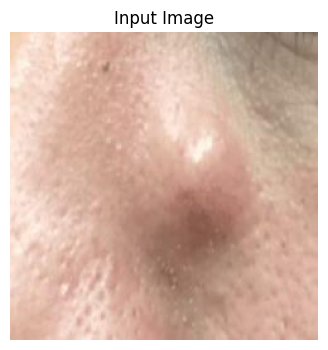

2026-06-09 13:16:08.188312: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Image path: /kaggle/input/datasets/sponishflea/classification-of-skin-diseases/train/acne/n8_JPG.rf.caf7830587e26e65cdb7dc1bbb5d119d.jpg
Prediction: acne
Confidence: 0.9994 (99.94%)

=== Prediksi untuk kelas Eksim ===


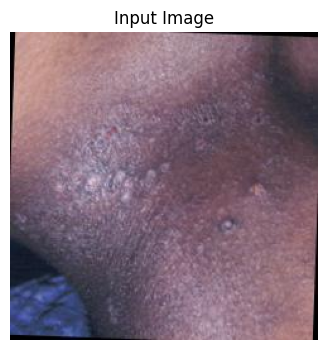

Image path: /kaggle/input/datasets/sponishflea/classification-of-skin-diseases/train/eksim/ek81_jpg.rf.bff2cc8428a4b1f5593aab746a5ceeb2.jpg
Prediction: eksim
Confidence: 0.7060 (70.60%)

=== Prediksi untuk kelas Rosacea ===


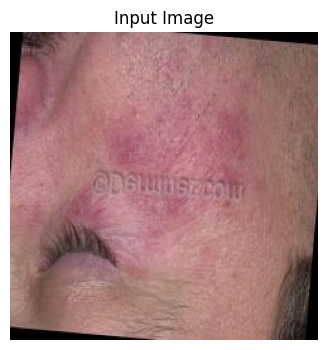

Image path: /kaggle/input/datasets/sponishflea/classification-of-skin-diseases/train/rosacea/ro84_jpg.rf.9944711515a48365547614aa2dddf2f5.jpg
Prediction: rosacea
Confidence: 0.9553 (95.53%)


In [ ]:
print("=== Prediksi untuk kelas Acne ===")
acne_images = df_filtered[df_filtered["labels"] == "acne"]["image_path"].tolist()
if len(acne_images) > 0:
    predict_and_show(acne_images[0])

print("\n=== Prediksi untuk kelas Eksim ===")
eksim_images = df_filtered[df_filtered["labels"] == "eksim"]["image_path"].tolist()
if len(eksim_images) > 0:
    predict_and_show(eksim_images[0])

print("\n=== Prediksi untuk kelas Rosacea ===")
rosacea_images = df_filtered[df_filtered["labels"] == "rosacea"]["image_path"].tolist()
if len(rosacea_images) > 0:
    predict_and_show(rosacea_images[0])

In [ ]:
print("="*50)
print("FINAL SUMMARY OF RESULTS")
print("="*50)
print(f"Dataset path: {base_path}")
print(f"Filtered classes: {desired_classes}")
print(f"Total images after filter: {len(df_filtered)}")
print(f"Train size: {len(train)}")
print(f"Validation size: {len(val)}")
print(f"Test size: {len(test)}")
print(f"Model Architecture: MobileNetV2 with Transfer Learning + Data Augmentation")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("="*50)

FINAL SUMMARY OF RESULTS
Dataset path: /kaggle/input/datasets/sponishflea/classification-of-skin-diseases/train
Filtered classes: ['acne', 'eksim', 'rosacea']
Total images after filter: 897
Train size: 717
Validation size: 90
Test size: 90
Model Architecture: MobileNetV2 with Transfer Learning + Data Augmentation
Test Accuracy: 83.33%
Test Loss: 0.5233


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("mobilenetv2_skin_3classes_ai.h5")

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step - accuracy: 0.8333 - loss: 0.5233
Test Accuracy: 0.8333
